# 01 — Mendeley Dataset Exploratory Data Analysis (EDA)

This notebook performs exploratory data analysis on the Mendeley Heart Disease dataset. The objective is to understand the dataset, examine feature distributions, identify missing values and duplicates, explore relationships with the target variable, perform statistical analysis, and derive insights for preprocessing and model development.

In [1]:
import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt

from scipy.stats import ttest_ind
from scipy.stats import chi2_contingency

sns.set_style("whitegrid")

In [2]:
RANDOM_STATE = 42

np.random.seed(RANDOM_STATE)

In [3]:
df = pd.read_csv("/Users/vamshi/Documents/ds_proj_cardiacx/data/raw/mendeley_heart_disease.csv")

df.head()

,patientid,age,gender,chestpain,restingBP,serumcholestrol,fastingbloodsugar,restingrelectro,maxheartrate,exerciseangia,oldpeak,slope,noofmajorvessels,target
0,103368,53,1,2,171,0,0,1,147,0,5.3,3,3,1
1,119250,40,1,0,94,229,0,1,115,0,3.7,1,1,0
2,119372,49,1,2,133,142,0,0,202,1,5.0,1,0,0
3,132514,43,1,0,138,295,1,1,153,0,3.2,2,2,1
4,146211,31,1,1,199,0,0,2,136,0,5.3,3,2,1


## Dataset Overview

In [4]:
print("Rows :", df.shape[0])
print("Columns :", df.shape[1])

df.info()

Rows : 1000
Columns : 14
<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   patientid          1000 non-null   int64  
 1   age                1000 non-null   int64  
 2   gender             1000 non-null   int64  
 3   chestpain          1000 non-null   int64  
 4   restingBP          1000 non-null   int64  
 5   serumcholestrol    1000 non-null   int64  
 6   fastingbloodsugar  1000 non-null   int64  
 7   restingrelectro    1000 non-null   int64  
 8   maxheartrate       1000 non-null   int64  
 9   exerciseangia      1000 non-null   int64  
 10  oldpeak            1000 non-null   float64
 11  slope              1000 non-null   int64  
 12  noofmajorvessels   1000 non-null   int64  
 13  target             1000 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 109.5 KB


In [5]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
patientid,1000.0,5.048704e+06,2.895905e+06,103368.0,2536439.50,4952508.5,7681877.00,9990855.0
age,1000.0,4.924200e+01,1.786473e+01,20.0,34.00,49.0,64.25,80.0
gender,1000.0,7.650000e-01,4.242110e-01,0.0,1.00,1.0,1.00,1.0
chestpain,1000.0,9.800000e-01,9.531571e-01,0.0,0.00,1.0,2.00,3.0
restingBP,1000.0,1.517470e+02,2.996523e+01,94.0,129.00,147.0,181.00,200.0
serumcholestrol,1000.0,3.114470e+02,1.324438e+02,0.0,235.75,318.0,404.25,602.0
fastingbloodsugar,1000.0,2.960000e-01,4.567194e-01,0.0,0.00,0.0,1.00,1.0
restingrelectro,1000.0,7.480000e-01,7.701228e-01,0.0,0.00,1.0,1.00,2.0
maxheartrate,1000.0,1.454770e+02,3.419027e+01,71.0,119.75,146.0,175.00,202.0
exerciseangia,1000.0,4.980000e-01,5.002462e-01,0.0,0.00,0.0,1.00,1.0


In [6]:
df.isnull().sum()

patientid            0
age                  0
gender               0
chestpain            0
restingBP            0
serumcholestrol      0
fastingbloodsugar    0
restingrelectro      0
maxheartrate         0
exerciseangia        0
oldpeak              0
slope                0
noofmajorvessels     0
target               0
dtype: int64

In [7]:
df.duplicated().sum()

np.int64(0)

## Target Distribution

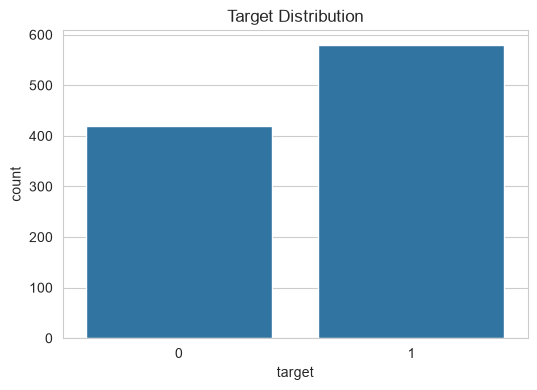

In [8]:
plt.figure(figsize=(6,4))

sns.countplot(
    data=df,
    x="target"
)

plt.title("Target Distribution")
plt.show()

In [9]:
df["target"].value_counts(normalize=True)*100

target
1    58.0
0    42.0
Name: proportion, dtype: float64

## Numerical Features Analysis

In [10]:
num_cols = [
    'age',
    'restingBP',
    'serumcholestrol',
    'maxheartrate',
    'oldpeak'
]

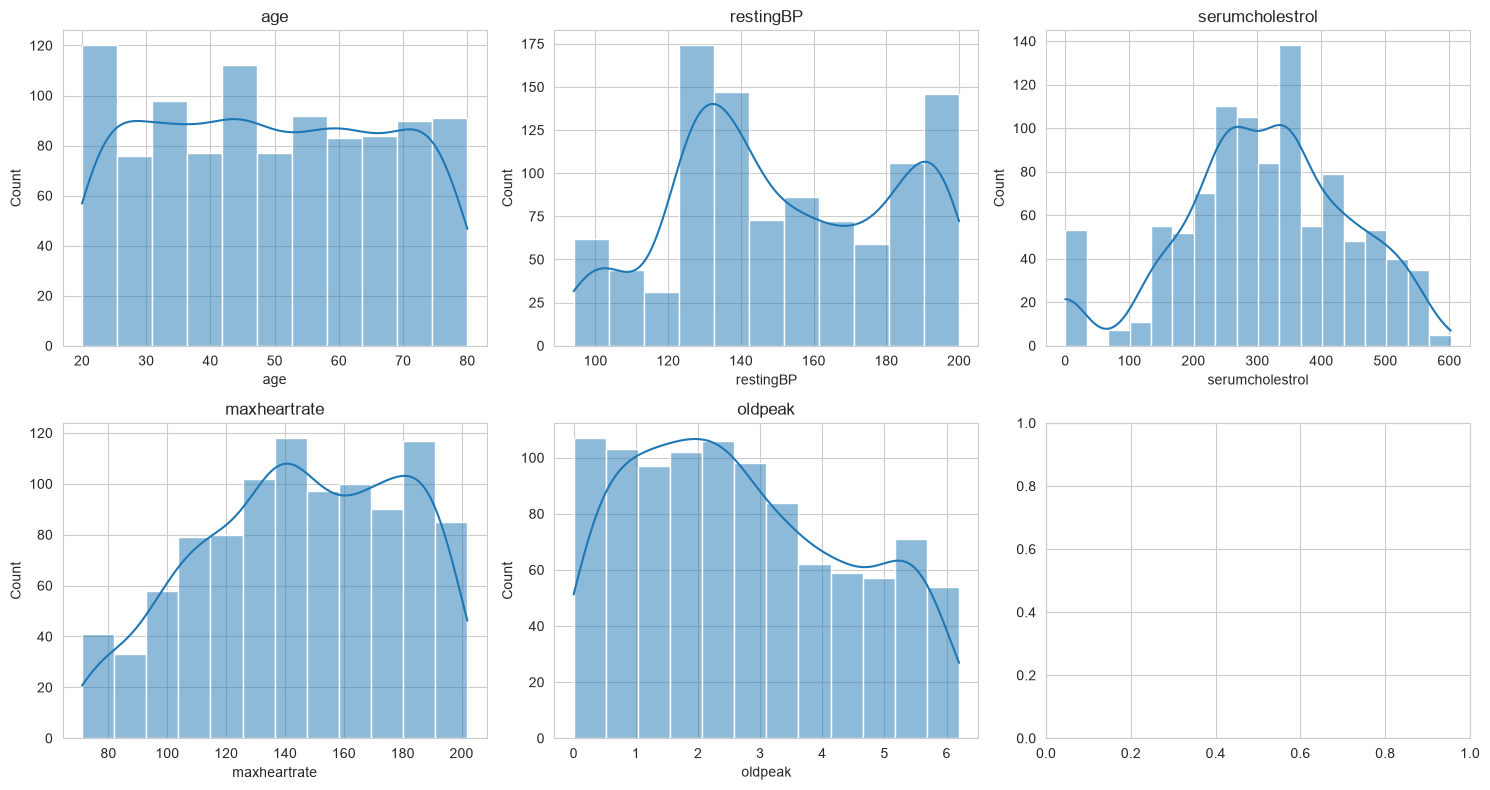

In [11]:
fig, axes = plt.subplots(2,3, figsize=(15,8))

axes = axes.flatten()

for i,col in enumerate(num_cols):

    sns.histplot(
        df[col],
        kde=True,
        ax=axes[i]
    )

    axes[i].set_title(col)

plt.tight_layout()
plt.show()

In [12]:
for col in num_cols:

    print(
        col,
        "Skewness =",
        round(df[col].skew(),3)
    )

age Skewness = 0.028
restingBP Skewness = 0.02
serumcholestrol Skewness = -0.307
maxheartrate Skewness = -0.251
oldpeak Skewness = 0.302


## Cholesterol Quality Check

In [13]:
df[df["serumcholestrol"]==0].shape

(53, 14)

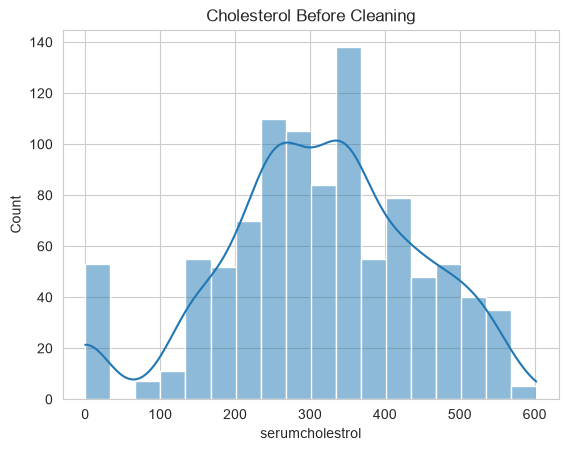

In [14]:
sns.histplot(
    df["serumcholestrol"],
    kde=True
)

plt.title("Cholesterol Before Cleaning")
plt.show()

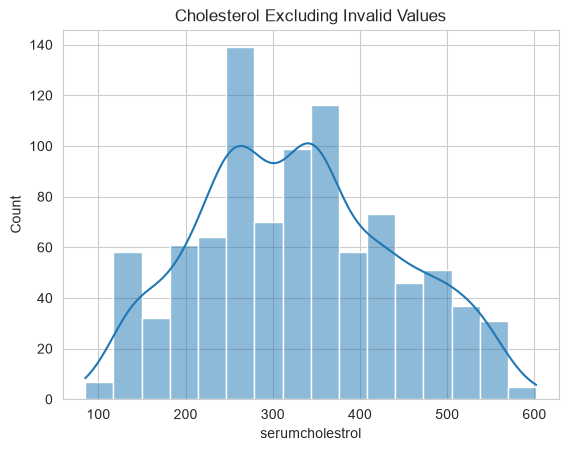

In [15]:
chol = df[
    df["serumcholestrol"] != 0
]["serumcholestrol"]

sns.histplot(
    chol,
    kde=True
)

plt.title(
    "Cholesterol Excluding Invalid Values"
)

plt.show()

### Distribution Analysis – Key Observations

The target classes are reasonably balanced, reducing the risk of model bias toward a dominant class and eliminating the immediate need for resampling techniques. Most numerical variables exhibit realistic clinical distributions; however, serum cholesterol contains several zero-valued entries that are medically implausible and likely represent recording errors. These values require correction during preprocessing. Age appears approximately normally distributed, while resting blood pressure, serum cholesterol, and oldpeak exhibit moderate skewness and a small number of extreme observations. These findings motivate feature scaling and data cleaning before model development.


## Categorical Features Analysis

In [16]:
cat_cols = [
    'gender',
    'chestpain',
    'fastingbloodsugar',
    'restingrelectro',
    'exerciseangia',
    'slope',
    'noofmajorvessels'
]

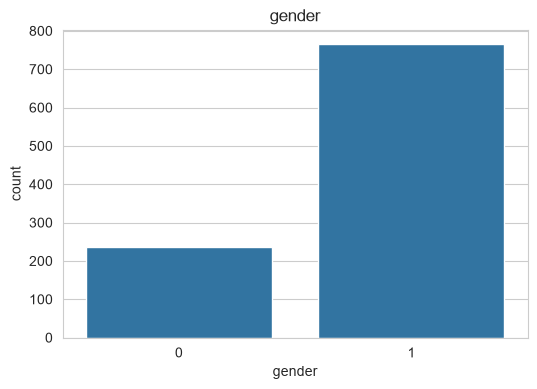

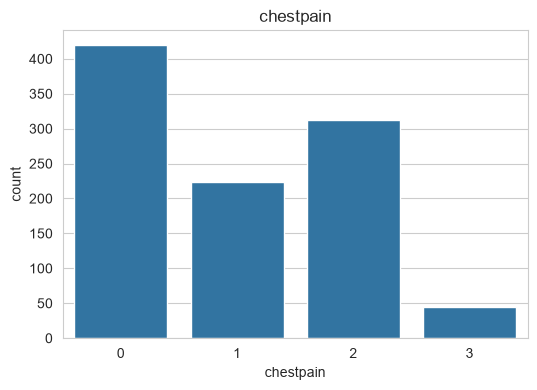

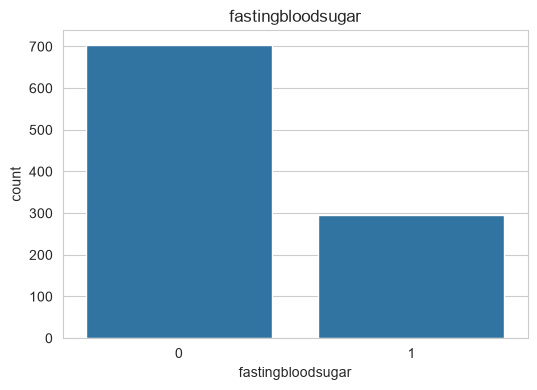

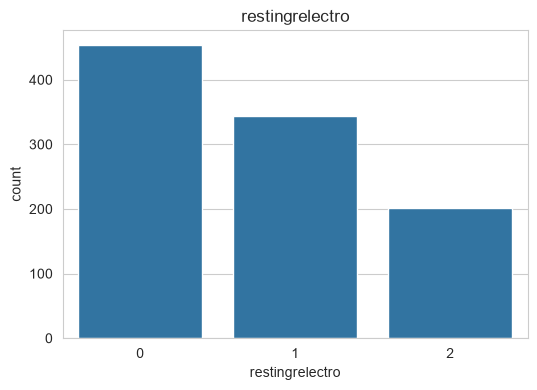

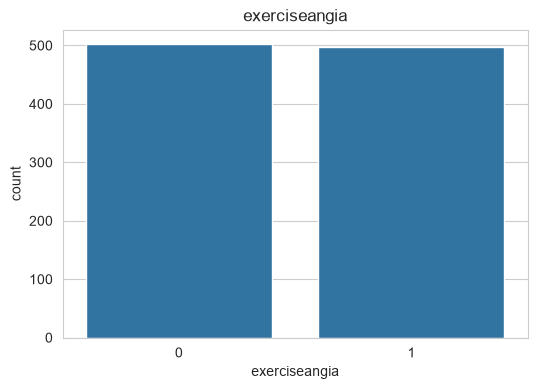

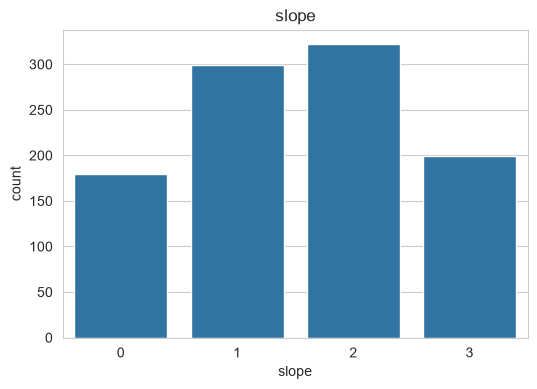

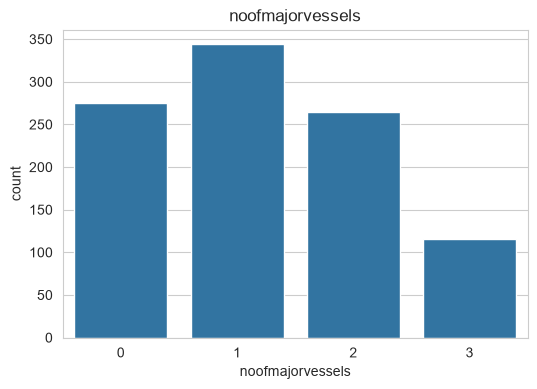

In [17]:
for col in cat_cols:
    plt.figure(figsize=(6,4))

    sns.countplot(
        data=df,
        x=col
    )
    plt.title(col)
    plt.show()

## Categorical Features vs Target

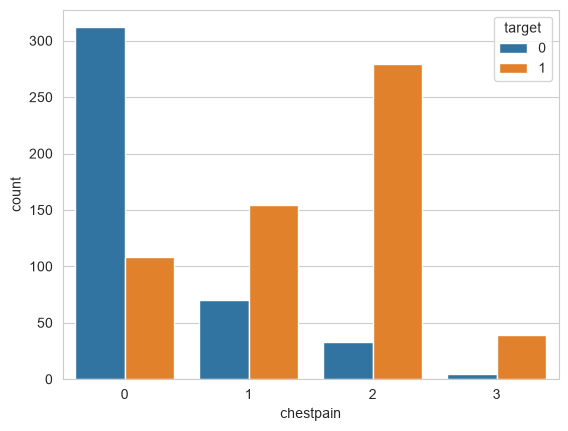

chestpain
0    0.257143
1    0.687500
2    0.894231
3    0.886364
Name: target, dtype: float64

In [18]:
sns.countplot(
    x='chestpain',
    hue='target',
    data=df
)

plt.show()

df.groupby(
    "chestpain"
)["target"].mean()

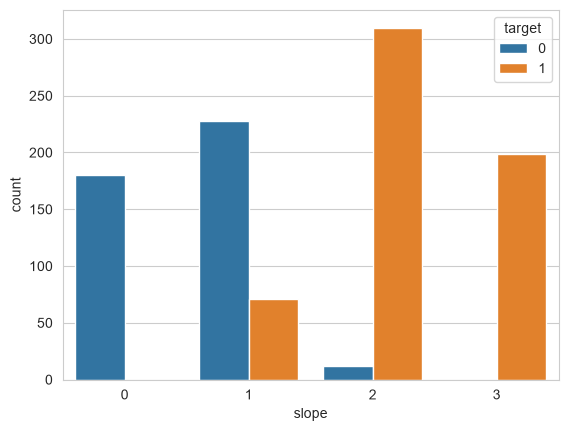

slope
0    0.000000
1    0.237458
2    0.962733
3    1.000000
Name: target, dtype: float64

In [19]:
sns.countplot(
    x='slope',
    hue='target',
    data=df
)

plt.show()

df.groupby(
    "slope"
)["target"].mean()

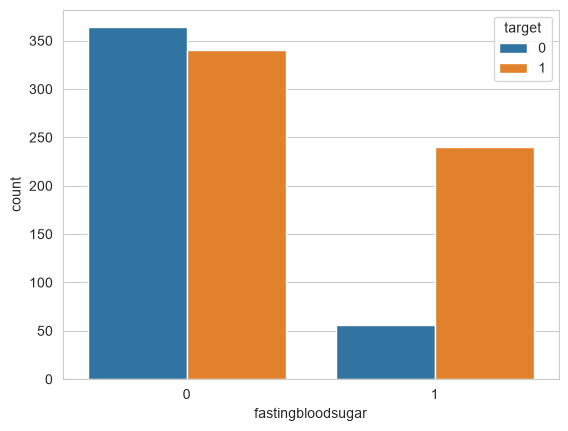

fastingbloodsugar
0    0.482955
1    0.810811
Name: target, dtype: float64

In [20]:
sns.countplot(
    x='fastingbloodsugar',
    hue='target',
    data=df
)

plt.show()

df.groupby(
    "fastingbloodsugar"
)["target"].mean()

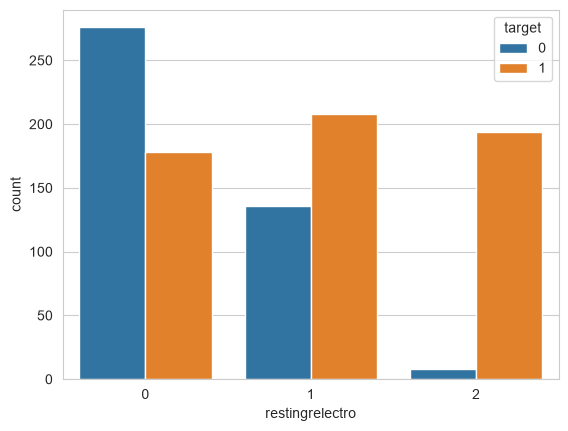

restingrelectro
0    0.392070
1    0.604651
2    0.960396
Name: target, dtype: float64

In [22]:
sns.countplot(
    x='restingrelectro',
    hue='target',
    data=df
)

plt.show()

df.groupby(
    "restingrelectro"
)["target"].mean()

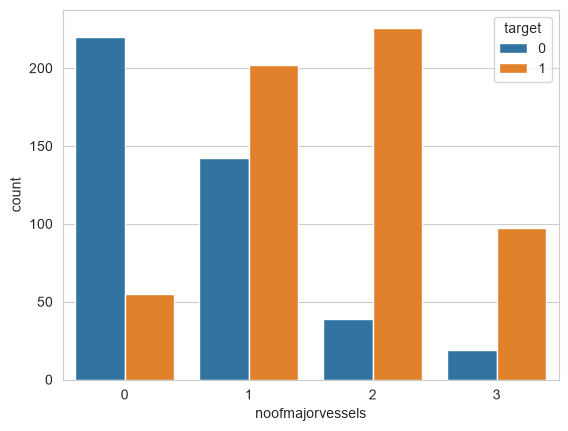

noofmajorvessels
0    0.200000
1    0.587209
2    0.852830
3    0.836207
Name: target, dtype: float64

In [23]:
sns.countplot(
    x='noofmajorvessels',
    hue='target',
    data=df
)

plt.show()

df.groupby(
    "noofmajorvessels"
)["target"].mean()

### Categorical Feature Analysis – Key Observations

Several categorical variables demonstrate strong relationships with heart disease occurrence. Chest pain type exhibits clear separation between healthy and diseased patients, indicating substantial diagnostic value. The slope of the ST segment appears to be one of the most influential predictors, with higher slope categories strongly associated with heart disease and lower categories predominantly associated with healthy individuals. The number of major vessels also shows a meaningful relationship with disease status. Resting ECG results and fasting blood sugar demonstrate weaker but still noticeable associations. Overall, these patterns suggest that categorical clinical indicators contribute significantly to cardiovascular risk assessment.


## Numerical Features vs Target

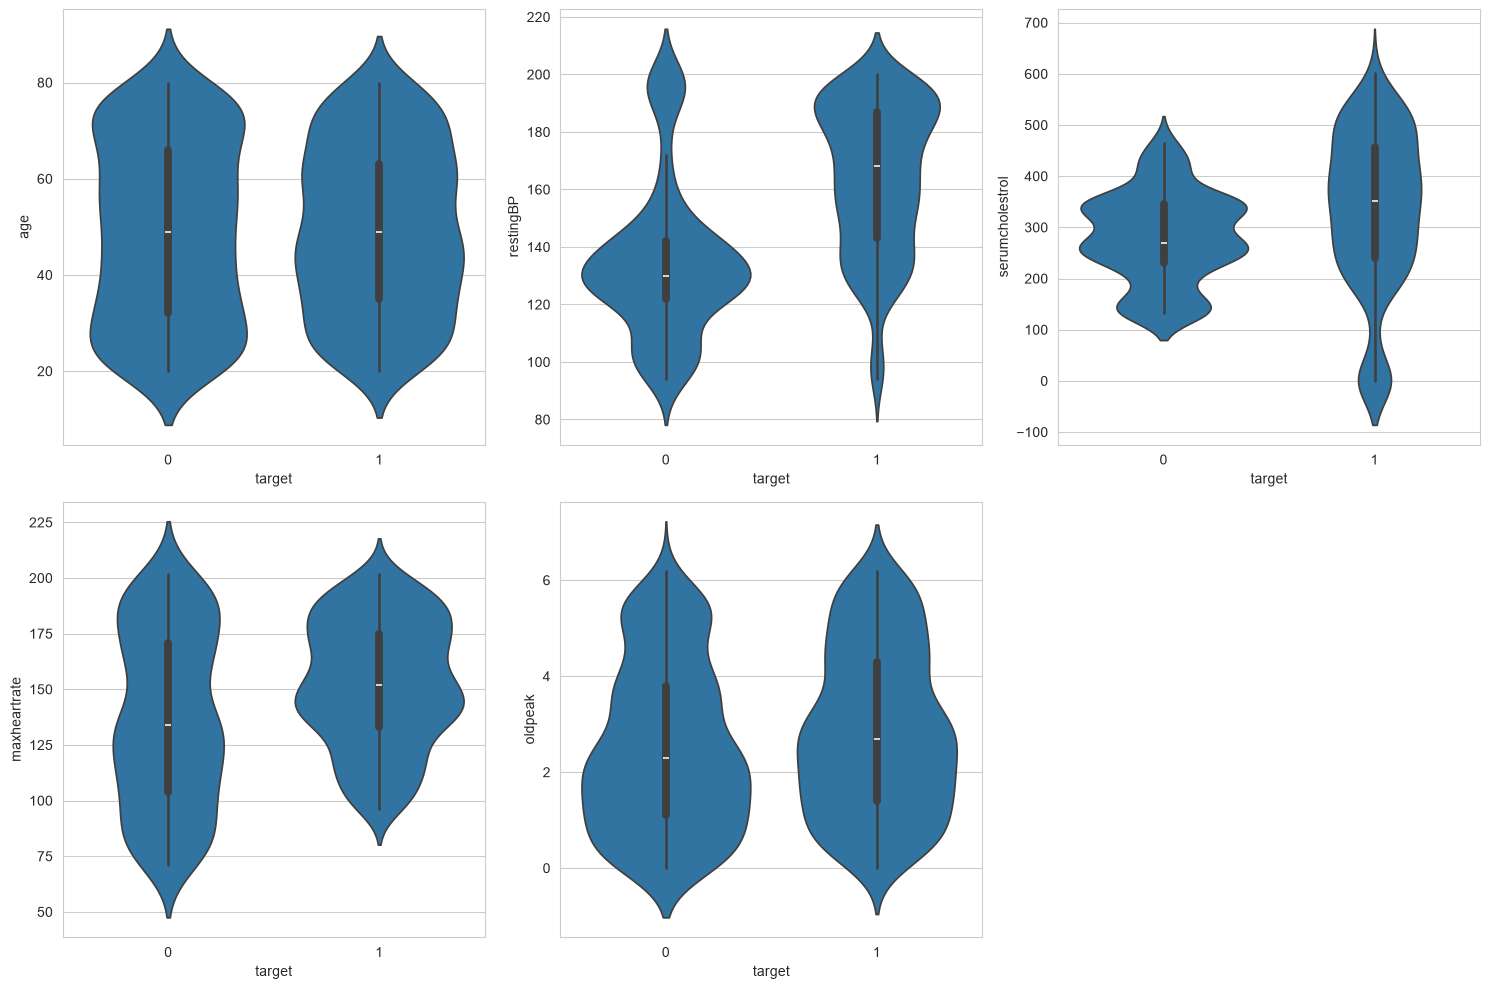

In [24]:
plt.figure(figsize=(15,10))

for i,col in enumerate(num_cols):

    plt.subplot(2,3,i+1)

    sns.violinplot(
        x='target',
        y=col,
        data=df
    )

plt.tight_layout()
plt.show()

### Numerical Feature Analysis – Key Observations

Comparison of numerical feature distributions between patients with and without heart disease reveals several clinically meaningful differences. Resting blood pressure, serum cholesterol, maximum heart rate, and oldpeak exhibit noticeable shifts between the two groups, suggesting strong predictive potential. In contrast, age shows relatively similar distributions across both classes, indicating a weaker independent effect within this dataset. The observed separation across multiple physiological measurements suggests that cardiovascular risk is influenced by a combination of clinical factors rather than a single dominant variable.


## Normality Assessment (QQ plots)

NameError: name 'stats' is not defined

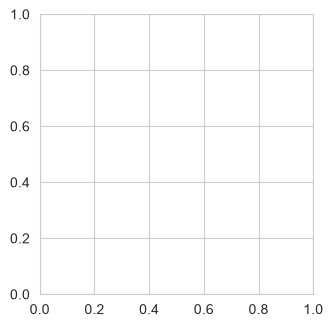

In [25]:
plt.figure(figsize=(12,8))

for i, col in enumerate(num_cols):
    plt.subplot(2,3,i+1)
    stats.probplot(df[col], dist="norm", plot=plt)
    plt.title(f"Q-Q Plot: {col}")

plt.tight_layout()
plt.show()

### Q-Q Plot Analysis

Q-Q plots were used to evaluate how closely the numerical variables follow a normal distribution. Most features exhibit points that generally align with the reference line, indicating approximate normality in the central region of the distribution. Minor deviations are observed in the tails, particularly for serum cholesterol and oldpeak, suggesting the presence of skewness and a small number of extreme observations. However, these deviations are not severe enough to invalidate subsequent statistical analysis. Overall, the numerical features demonstrate sufficiently reasonable distributional behavior for exploratory statistical testing and machine learning modelling.


## Statistical Analysis

### T-Test

In [26]:
for col in num_cols:

    group1 = df[
        df["target"] == 0
    ][col]

    group2 = df[
        df["target"] == 1
    ][col]

    stat,p = ttest_ind(
        group1,
        group2
    )

    print(
        f"{col}: p={p:.5f}"
    )

age: p=0.79185
restingBP: p=0.00000
serumcholestrol: p=0.00000
maxheartrate: p=0.00000
oldpeak: p=0.00191


### Chi-Square Test

In [27]:
for col in cat_cols:

    table = pd.crosstab(
        df[col],
        df["target"]
    )

    chi2,p,dof,exp = chi2_contingency(table)

    print(
        f"{col}: p={p:.5f}"
    )

gender: p=0.67221
chestpain: p=0.00000
fastingbloodsugar: p=0.00000
restingrelectro: p=0.00000
exerciseangia: p=0.23136
slope: p=0.00000
noofmajorvessels: p=0.00000


## Correlation Analysis

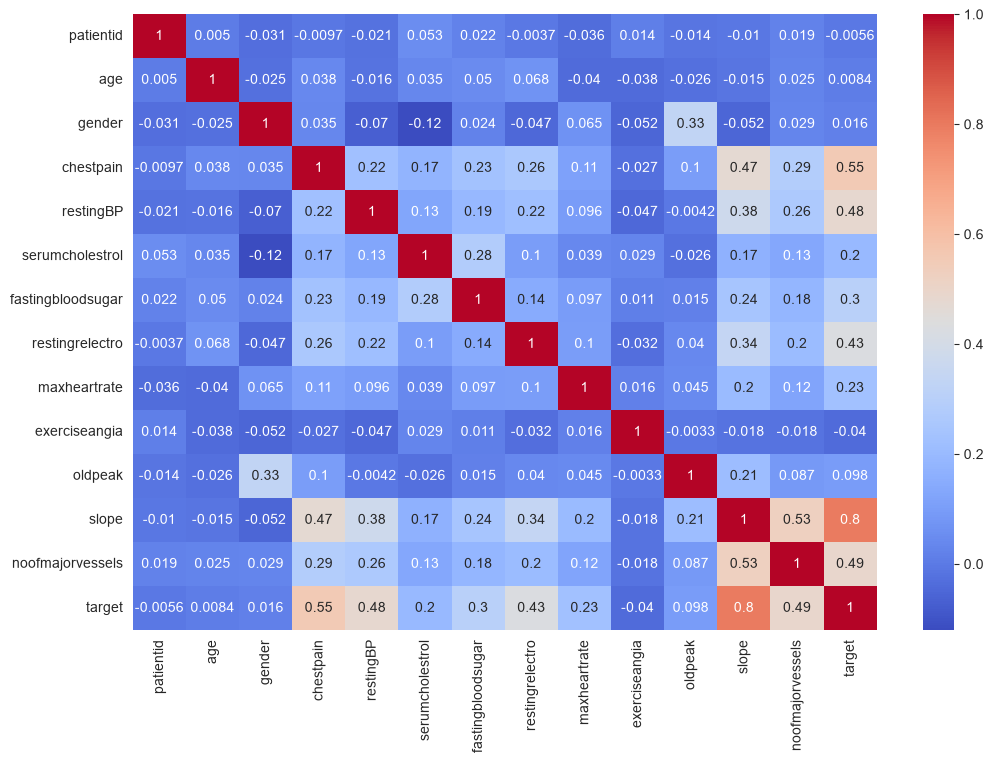

In [28]:
plt.figure(figsize=(12,8))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.show()

### Final EDA Summary

Statistical testing confirms many of the patterns observed visually during exploratory analysis. Continuous variables such as resting blood pressure, serum cholesterol, and maximum heart rate demonstrate significant differences between disease and non-disease populations, while categorical variables including chest pain type, resting ECG, fasting blood sugar, slope, and number of major vessels show strong associations with the target variable. Correlation analysis indicates the absence of severe multicollinearity, allowing all clinically relevant attributes to be retained for modelling. Overall, the dataset is well-structured, clinically meaningful, and highly suitable for machine learning–based heart disease prediction. The exploratory analysis also identifies several key predictors that are expected to play an important role in subsequent model training and explainability studies.
